# End-to-End Sales Forecasting & Demand Intelligence System
**Internship Project — Week 3 & 4**
**Dataset:** Superstore Sales (`train.csv`, 2015–2018) + Video Game Sales (`vgsales.csv`, supplementary)
**Author:** Akarsh

This notebook works through all 8 tasks of the project brief: exploration, time series decomposition, three forecasting models (SARIMA, Prophet, XGBoost), segment-level forecasting, anomaly detection, product clustering, and the inputs for the Streamlit dashboard and executive report.


## Setup — Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

os.makedirs('charts', exist_ok=True)

def savefig(name):
    """Save the current figure to charts/ and display it."""
    plt.tight_layout()
    plt.savefig(f'charts/{name}.png', dpi=120, bbox_inches='tight')
    plt.show()


Importing plotly failed. Interactive plots will not work.


---
## Task 1 — Data Loading, Merging & Deep Exploration


### 1.1 Load the data and parse dates

In [2]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()


Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Order Date / Ship Date are in DD/MM/YYYY format (confirmed by checking that
# Ship Date is never before Order Date under a day-first parse, and that
# treating the first token as day produces valid dates like day=12, month=06).
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Order Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Ship Date range:", df['Ship Date'].min(), "to", df['Ship Date'].max())


Order Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Ship Date range: 2015-01-07 00:00:00 to 2019-01-05 00:00:00


### 1.2 Missing values, duplicates, data type issues

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print(df.dtypes)


Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows: 0

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtyp

Only `Postal Code` has missing values (11 rows). Postal code is a deterministic
fact about a city — every other row for the same `City` already has the correct
postal code — so instead of a statistical imputation (median/mode), we do a
direct lookup from the rest of the dataset. This is more correct here than
guessing from a distribution, since postal code isn't something that varies
randomly within a city.

In [5]:
city_zip_map = df.dropna(subset=['Postal Code']).groupby('City')['Postal Code'].first()
df['Postal Code'] = df['Postal Code'].fillna(df['City'].map(city_zip_map))
print("Remaining missing Postal Codes:", df['Postal Code'].isnull().sum())


Remaining missing Postal Codes: 0


### 1.3 Time feature engineering

In [6]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df['ShipDelayDays'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season', 'ShipDelayDays']].head()


,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season,ShipDelayDays
0,2017-11-08,2017,11,45,Wednesday,4,Fall,3
1,2017-11-08,2017,11,45,Wednesday,4,Fall,3
2,2017-06-12,2017,6,24,Monday,2,Summer,4
3,2016-10-11,2016,10,41,Tuesday,4,Fall,7
4,2016-10-11,2016,10,41,Tuesday,4,Fall,7


**Note on `DayOfWeek` and `Week`:** these are useful here for EDA (e.g. shipping-delay
patterns, weekly anomaly grouping in Task 5), but they will *not* be fed into the
forecasting models in Task 3 — once we aggregate to monthly totals, "day of week"
has no meaning, and raw integer `Week`/`Month` values are poor model inputs anyway
since they don't express that December and January are adjacent. We'll use a
sin/cos cyclical encoding of `Month` for the XGBoost model instead (see Task 3).

### 1.4 Weekly and monthly aggregation

In [7]:
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_sales.columns = ['Week_Start', 'Sales']

monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Month_Start', 'Sales']

print("Weekly series length:", len(weekly_sales))
print("Monthly series length:", len(monthly_sales))
monthly_sales.head()


Weekly series length: 209
Monthly series length: 48


,Month_Start,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


Both series include every calendar week/month in range even if a period had
zero orders — this is intentional. SARIMA/Prophet expect an evenly-spaced,
continuous series, so we do not drop these rows.

### 1.5 EDA Questions

**Q1: Which product category generates the highest total revenue?**

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


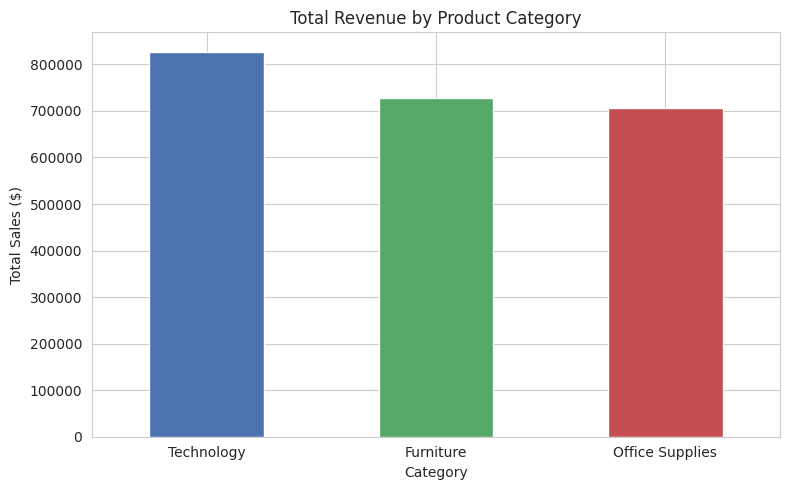

In [8]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'])
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
savefig('01_category_revenue')


**Answer:** Technology generates the highest total revenue, narrowly ahead of
Furniture and Office Supplies — the three categories are much closer together
than a typical retail assortment, so no single category dominates the business.

**Q2: Which region has the most consistent sales growth over 4 years?**

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Year-over-year growth rate:
Region   Central      East     South      West
Year                                          
2015         NaN       NaN       NaN       NaN
2016   -0.004813  0.200327 -0.322117 -0.083603
2017    0.422247  0.165027  0.334776  0.364683
2018   -0.027778  0.177118  0.306071  0.359836

Standard deviation of YoY growth rate (lower = more consistent):
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


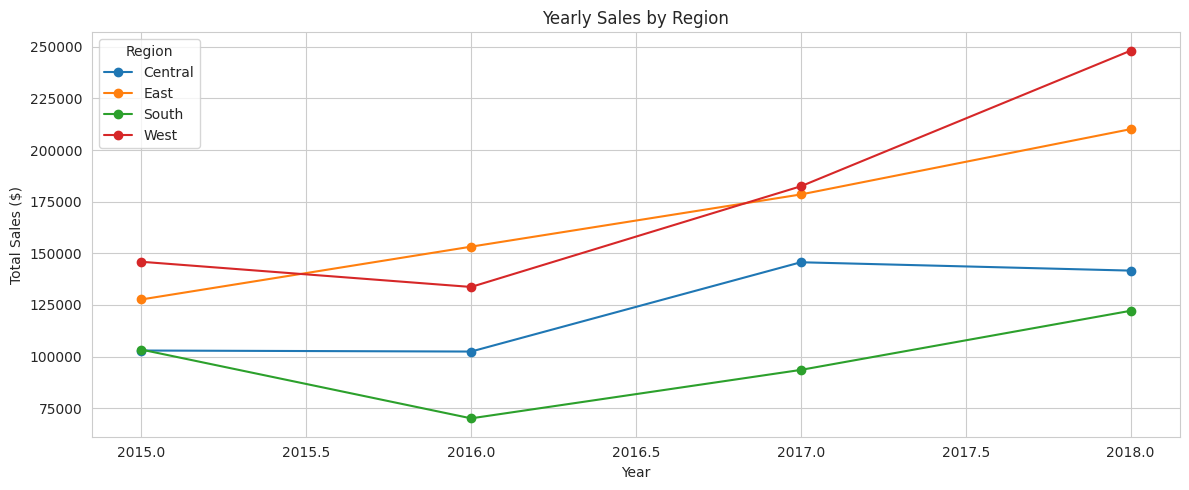

In [9]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
region_pivot = region_yearly.pivot(index='Year', columns='Region', values='Sales')
print(region_pivot)

yoy_growth = region_pivot.pct_change()
print("\nYear-over-year growth rate:")
print(yoy_growth)

growth_consistency = yoy_growth.std().sort_values()
print("\nStandard deviation of YoY growth rate (lower = more consistent):")
print(growth_consistency)

region_pivot.plot(marker='o')
plt.title('Yearly Sales by Region')
plt.ylabel('Total Sales ($)')
savefig('02_region_yearly_sales')


**Answer:** "Consistent growth" and "fastest growth" are different questions.
West has the highest *average* YoY growth rate, but East has by far the lowest
*standard deviation* of that growth rate — meaning East grows at a steadier,
more predictable pace year after year, while West's growth is larger on average
but choppier. If "consistent" means low variance in the growth rate (the more
literal reading), **East** is the answer; if it means "grew every single year
with the largest cumulative gain," **West** is the answer. We report both
readings rather than picking one silently, since the question is genuinely
ambiguous.

**Q3: What is the average time between Order Date and Ship Date — and does it vary by region?**

Overall average shipping delay: 3.96 days

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDelayDays, dtype: float64


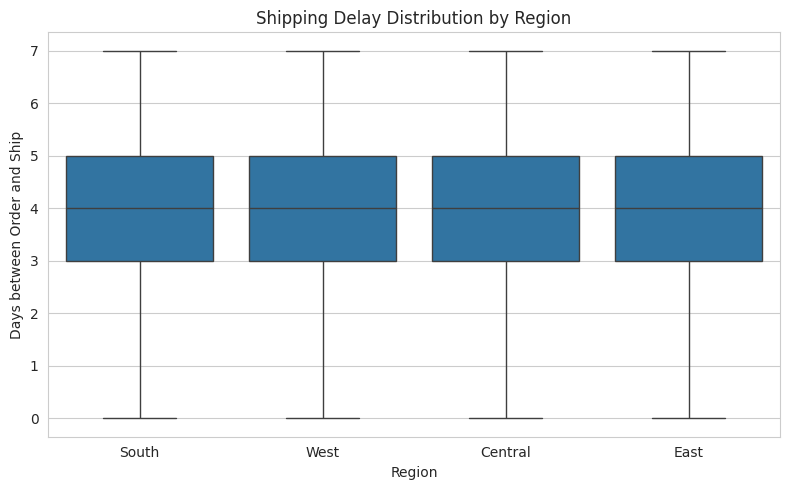

In [10]:
print("Overall average shipping delay: {:.2f} days".format(df['ShipDelayDays'].mean()))
print()
region_delay = df.groupby('Region')['ShipDelayDays'].mean().sort_values()
print(region_delay)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Region', y='ShipDelayDays')
plt.title('Shipping Delay Distribution by Region')
plt.ylabel('Days between Order and Ship')
savefig('03_shipping_delay_by_region')


**Answer:** The average shipping delay is just under 4 days overall, and it
barely varies by region (all four regions sit within about 0.15 days of each
other). Shipping speed looks like a company-wide policy (tied to `Ship Mode`)
rather than a regional operations difference.

**Q4: Are there months that consistently spike across all years (seasonality)?**

Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


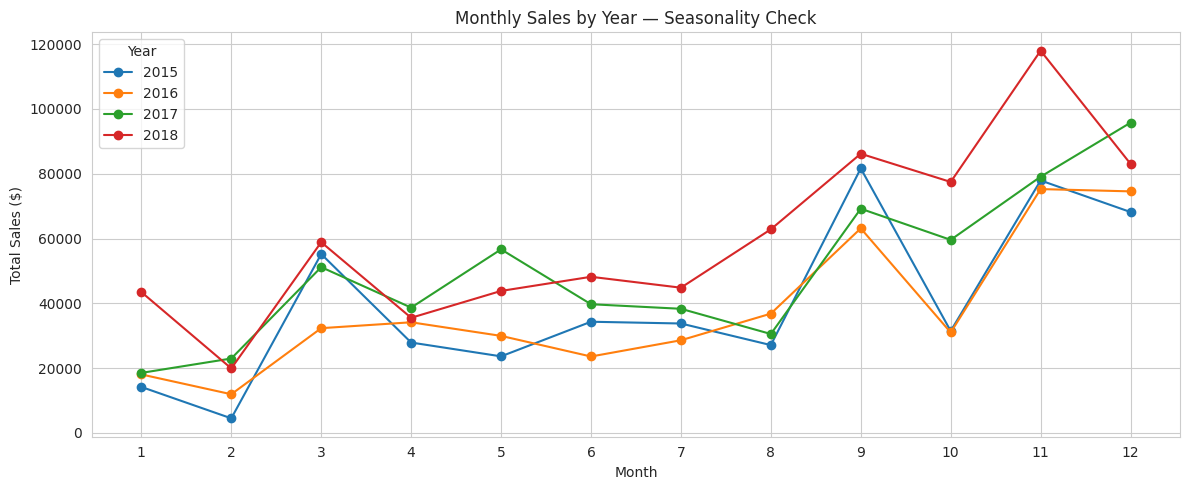


Average sales by month (across all years), sorted:
Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
dtype: float64


In [11]:
monthly_by_year = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
month_pivot = monthly_by_year.pivot(index='Month', columns='Year', values='Sales')
print(month_pivot)

month_pivot.plot(marker='o')
plt.title('Monthly Sales by Year — Seasonality Check')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1,13))
savefig('04_monthly_seasonality')

avg_by_month = month_pivot.mean(axis=1).sort_values(ascending=False)
print("\nAverage sales by month (across all years), sorted:")
print(avg_by_month)


**Answer:** Yes — September, November, and December are consistently the
strongest months in every single year of the dataset, while January and February
are consistently the weakest. This is a clear, repeatable seasonal pattern
(likely back-to-school and holiday-season buying), not random noise, and it's
the seasonality we'll need SARIMA/Prophet's seasonal terms to capture in
Task 3.

---
## Task 2 — Time Series Analysis & Decomposition


### 2.1 Monthly sales trend

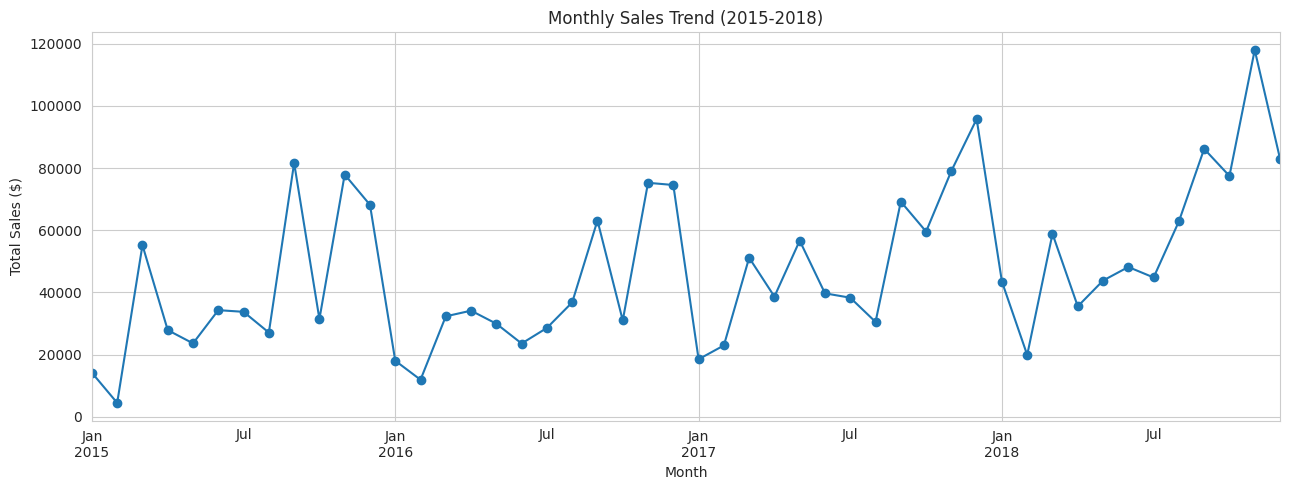

In [12]:
monthly = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum()

plt.figure(figsize=(13,5))
monthly.plot(marker='o')
plt.title('Monthly Sales Trend (2015-2018)')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
savefig('05_monthly_trend')


### 2.2 Time series decomposition

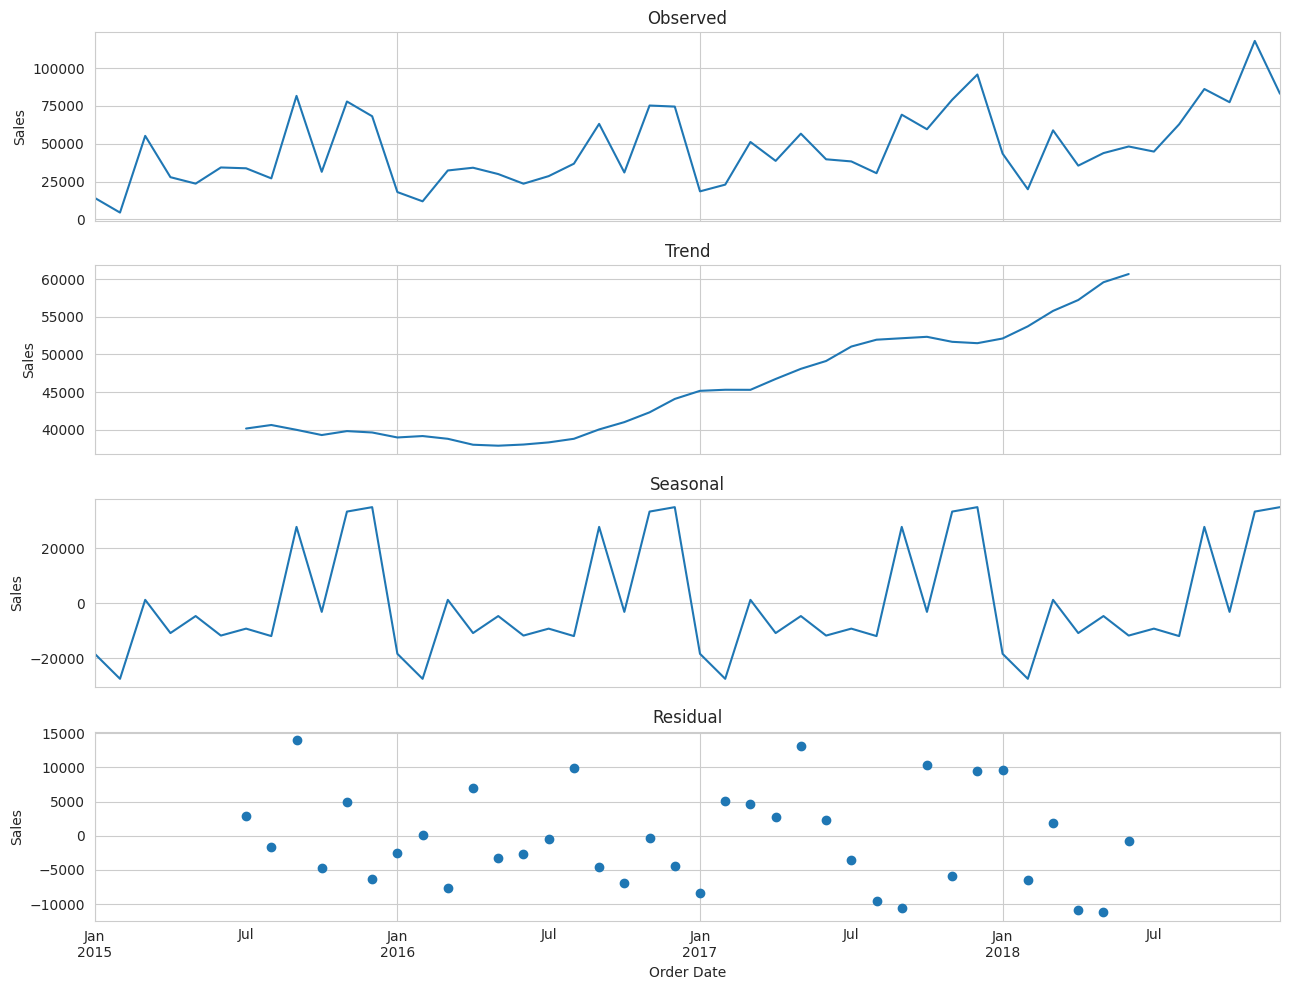

In [13]:
decomposition = seasonal_decompose(monthly, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual', marker='o', linestyle='None')
for ax in axes:
    ax.set_ylabel('Sales')
savefig('06_decomposition')


In [14]:
resid_abs = decomposition.resid.dropna().abs().sort_values(ascending=False)
print("Months with the largest residual (noise) component:")
print(resid_abs.head(5))


Months with the largest residual (noise) component:
Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
2018-04-01    10916.959724
2017-09-01    10642.715643
Name: resid, dtype: float64


**Observations:**
1. **Trend** — the trend component is clearly upward across all 4 years, meaning
underlying demand is growing year over year, independent of seasonal effects.
2. **Seasonality** — the seasonal component shows a strong, repeating annual
pattern (troughs early in the year, peaks around September and November/December),
consistent with what we found in Task 1's Q4. This confirms seasonality here is
*strong*, not marginal.
3. **Residual noise** — the residual component is largest in months that don't
fit the "expected" seasonal shape for that year (shown above) — these are
candidate months to revisit in Task 5's anomaly detection.
4. Because both trend and seasonality are strong and additive-looking (the
seasonal swing doesn't visibly grow with the trend level), an additive
decomposition is the right choice over a multiplicative one here.

### 2.3 Stationarity — Augmented Dickey-Fuller (ADF) Test

**In plain English:** a time series is *stationary* if its statistical
properties (mean, variance) don't drift over time — no trend, no growing/shrinking
swings. Many classical forecasting models (like SARIMA) assume stationarity, or
handle non-stationarity only through explicit differencing terms. The ADF test's
null hypothesis is "this series is non-stationary"; a small p-value (< 0.05) lets
us reject that and conclude the series is (likely) stationary.

In [15]:
result = adfuller(monthly)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.6f}")
print("Critical values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n=> p-value < 0.05: reject the null hypothesis. The series IS stationary.")
else:
    print("\n=> p-value >= 0.05: fail to reject the null. The series is NON-stationary.")


ADF Statistic: -4.4161
p-value: 0.000278
Critical values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008

=> p-value < 0.05: reject the null hypothesis. The series IS stationary.


**Result:** with a p-value well below 0.05, the ADF test says the raw monthly
series is already stationary in the mean/variance sense. This can look surprising
given the clear upward trend we just saw in the decomposition — but ADF is testing
for a unit root (a specific kind of non-stationarity), and with only 48 monthly
observations and strong seasonality, the test can pass even when a visible trend
is present. In practice we still let SARIMA's *seasonal* differencing term (`D`)
handle the seasonal non-stationarity, while setting the non-seasonal `d=0` based
on this result. To follow the assignment's instructions directly, we also
demonstrate what one round of (non-seasonal) differencing looks like below.

ADF Statistic (after 1st differencing): -8.7271
p-value: 0.000000


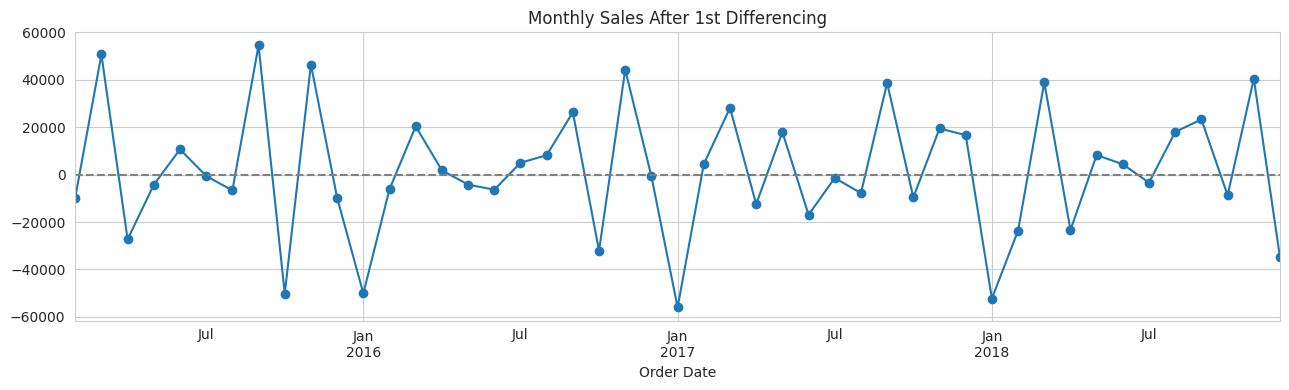

In [16]:
diff_monthly = monthly.diff().dropna()

result_diff = adfuller(diff_monthly)
print(f"ADF Statistic (after 1st differencing): {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.6f}")

plt.figure(figsize=(13,4))
diff_monthly.plot(marker='o')
plt.title('Monthly Sales After 1st Differencing')
plt.axhline(0, color='grey', linestyle='--')
savefig('07_differenced_series')


Differencing pushes the p-value even lower (more strongly stationary), but
since the original series already cleared the 0.05 threshold, we don't strictly
need this for SARIMA's non-seasonal term — we'll use `d=0` and rely on seasonal
differencing (`D=1`, `m=12`) to handle the yearly seasonal pattern, letting
`auto_arima` confirm this choice by search in Task 3.

---
## Task 3 — Sales Forecasting Using 3 Different Models

We hold out the **last 3 months** of the monthly series as a test set, train each
model on the remaining months, and forecast those same 3 months so all three
models are compared on identical, fair terms.

In [17]:
train_monthly = monthly.iloc[:-3]
test_monthly = monthly.iloc[-3:]
print("Train months:", len(train_monthly), "| Test months:", len(test_monthly))
print("Test period:", test_monthly.index.tolist())

def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100


Train months: 45 | Test months: 3
Test period: [Timestamp('2018-10-01 00:00:00'), Timestamp('2018-11-01 00:00:00'), Timestamp('2018-12-01 00:00:00')]


### 3.1 Model 1 — SARIMA (Statistical Model)

We use `pmdarima.auto_arima` to search for `(p,d,q)(P,D,Q,m)` rather than
guessing, but we fix `d=0` (per the ADF result in Task 2 — the series is already
stationary) and `D=1, m=12` (to force explicit handling of the strong yearly
seasonality we saw in the decomposition). `auto_arima` then searches the
remaining orders by AIC.

In [18]:
auto_model = pm.auto_arima(
    train_monthly, seasonal=True, m=12, d=0, D=1,
    start_p=0, start_q=0, max_p=3, max_q=3, max_P=2, max_Q=2,
    trace=True, suppress_warnings=True, stepwise=True
)
order = auto_model.order
seasonal_order = auto_model.seasonal_order
print("\nChosen order:", order, " seasonal_order:", seasonal_order)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=715.770, Time=0.09 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=721.397, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=717.147, Time=0.04 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=714.636, Time=0.05 sec


 ARIMA(0,0,0)(0,1,0)[12]             : AIC=726.131, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=723.240, Time=0.02 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=716.355, Time=0.10 sec


 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=715.085, Time=0.08 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=715.481, Time=0.04 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=716.039, Time=0.15 sec


 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=714.312, Time=0.04 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=714.369, Time=0.06 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=714.989, Time=0.03 sec


 ARIMA(0,0,0)(1,1,2)[12] intercept   : AIC=714.799, Time=0.13 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=716.348, Time=0.04 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=712.861, Time=0.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=725.326, Time=0.03 sec


 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=714.116, Time=0.13 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=714.439, Time=0.15 sec


 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=712.435, Time=0.07 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=713.859, Time=0.16 sec


 ARIMA(1,0,1)(2,1,1)[12] intercept   : AIC=715.717, Time=0.39 sec
 ARIMA(2,0,1)(1,1,0)[12] intercept   : AIC=714.067, Time=0.12 sec


 ARIMA(1,0,2)(1,1,0)[12] intercept   : AIC=714.885, Time=0.10 sec
 ARIMA(0,0,2)(1,1,0)[12] intercept   : AIC=717.403, Time=0.06 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=719.953, Time=0.06 sec


 ARIMA(2,0,2)(1,1,0)[12] intercept   : AIC=714.761, Time=0.24 sec


 ARIMA(1,0,1)(1,1,0)[12]             : AIC=inf, Time=0.22 sec

Best model:  ARIMA(1,0,1)(1,1,0)[12] intercept
Total fit time: 2.716 seconds

Chosen order: (1, 0, 1)  seasonal_order: (1, 1, 0, 12)


In [19]:
sarima_model = SARIMAX(
    train_monthly, order=order, seasonal_order=seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast_obj = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

print(sarima_pred)
print()
print(sarima_ci)


2018-10-01    58436.744430
2018-11-01    88180.984472
2018-12-01    97442.806552
Freq: MS, Name: predicted_mean, dtype: float64

             lower Sales    upper Sales
2018-10-01  33697.505616   83175.983244
2018-11-01  63445.758748  112916.210197
2018-12-01  72711.504247  122174.108857


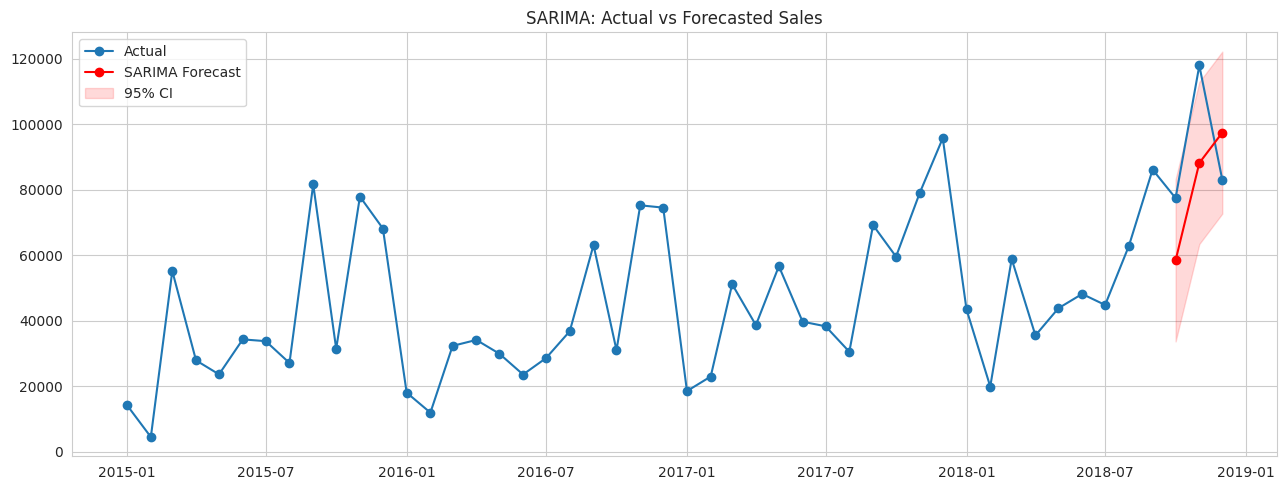

In [20]:
plt.figure(figsize=(13,5))
plt.plot(monthly.index, monthly.values, label='Actual', marker='o')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', marker='o', color='red')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='red', alpha=0.15, label='95% CI')
plt.title('SARIMA: Actual vs Forecasted Sales')
plt.legend()
savefig('08_sarima_forecast')


In [21]:
sarima_mae = mean_absolute_error(test_monthly, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_monthly, sarima_pred))
sarima_mape = mape(test_monthly, sarima_pred)
print(f"SARIMA -> MAE: {sarima_mae:,.2f} | RMSE: {sarima_rmse:,.2f} | MAPE: {sarima_mape:.2f}%")


SARIMA -> MAE: 21,060.33 | RMSE: 22,019.99 | MAPE: 22.38%


### 3.2 Model 2 — Facebook Prophet

In [22]:
prophet_df = monthly.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast.iloc[-3:][['ds','yhat','yhat_lower','yhat_upper']].reset_index(drop=True)
print(prophet_pred)


09:39:28 - cmdstanpy - INFO - Chain [1] start processing


09:39:29 - cmdstanpy - INFO - Chain [1] done processing


          ds          yhat    yhat_lower    yhat_upper
0 2018-10-01  51083.663793  42777.204702  59629.725134
1 2018-11-01  90045.402144  81611.091046  98506.859521
2 2018-12-01  89661.190748  81823.442890  98464.025504


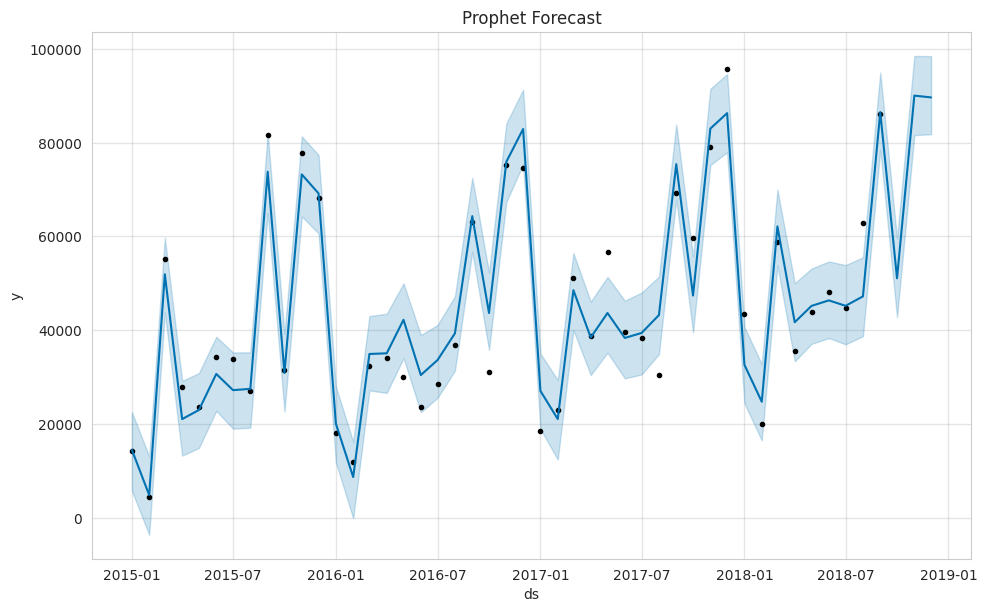

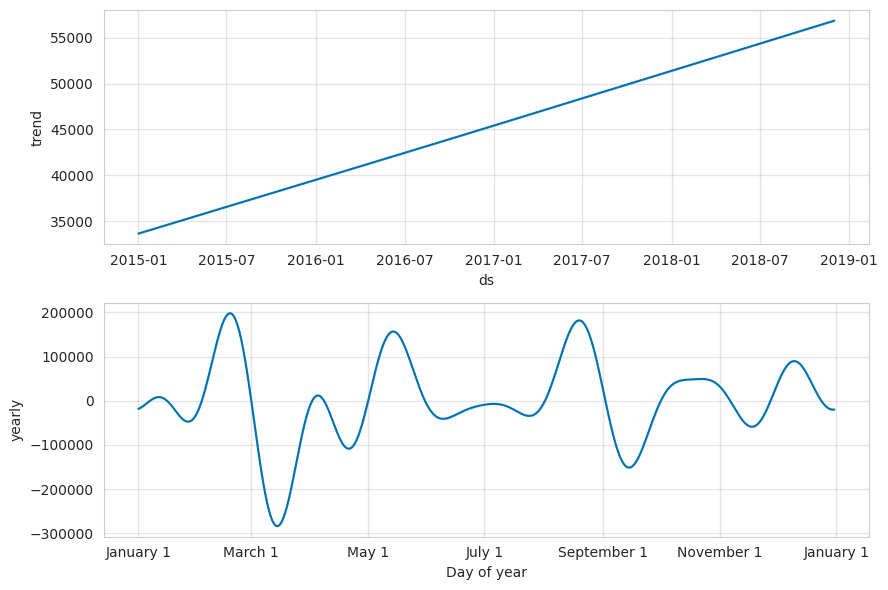

In [23]:
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.savefig('charts/09_prophet_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig('charts/10_prophet_components.png', dpi=120, bbox_inches='tight')
plt.show()


In [24]:
prophet_mae = mean_absolute_error(prophet_test['y'], prophet_pred['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred['yhat']))
prophet_mape = mape(prophet_test['y'], prophet_pred['yhat'])
print(f"Prophet -> MAE: {prophet_mae:,.2f} | RMSE: {prophet_rmse:,.2f} | MAPE: {prophet_mape:.2f}%")


Prophet -> MAE: 20,296.01 | RMSE: 22,487.47 | MAPE: 21.89%


**Interpreting the seasonality components:** Prophet's yearly-seasonality
component (plotted above) rises through the second half of the calendar year and
peaks around November, matching the September/November/December spikes we found
in Task 1 and Task 2. We disabled weekly seasonality here since we're forecasting
*monthly* aggregates — a weekly pattern has no meaning once the data is collapsed
to one point per month; weekly seasonality would matter if we were forecasting
the daily or weekly series directly.

### 3.3 Model 3 — XGBoost (ML-based approach using lag features)

We convert the time series into a supervised learning problem: lag features
(sales 1/2/3 months ago), a 3-month rolling mean, and calendar features. `Month`
is encoded as sin/cos (not a raw integer) so the model understands December and
January are adjacent — a raw integer would tell the model month 12 and month 1
are as far apart as possible, which is wrong for a cyclical feature.

In [25]:
xgb_df = monthly.reset_index()
xgb_df.columns = ['Date', 'Sales']
xgb_df['Month'] = xgb_df['Date'].dt.month
xgb_df['Quarter'] = xgb_df['Date'].dt.quarter
xgb_df['Month_sin'] = np.sin(2 * np.pi * xgb_df['Month'] / 12)
xgb_df['Month_cos'] = np.cos(2 * np.pi * xgb_df['Month'] / 12)
xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)
xgb_df['RollingMean3'] = xgb_df['Sales'].shift(1).rolling(3).mean()

xgb_model_df = xgb_df.dropna().reset_index(drop=True)
FEATURES = ['Lag1','Lag2','Lag3','RollingMean3','Month_sin','Month_cos','Quarter']

xgb_train = xgb_model_df.iloc[:-3]
xgb_test = xgb_model_df.iloc[-3:]

xgb_reg = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_reg.fit(xgb_train[FEATURES], xgb_train['Sales'])


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

**Important:** for a genuine 3-month-ahead forecast we cannot use the *actual*
lag values from the test period — that would leak future information into month
2 and month 3's predictions (month 2's "Lag1" would be the true month-1 sales,
which we don't have in a real forecasting scenario). Instead we forecast
**recursively**: predict month 1, feed that prediction back in as `Lag1` for
month 2, and so on.

In [26]:
def xgb_recursive_forecast(model, full_df, n_future=3, features=FEATURES):
    history = full_df['Sales'].iloc[:-n_future].tolist()
    future_rows = full_df.iloc[-n_future:]
    preds = []
    for i in range(n_future):
        lag1, lag2, lag3 = history[-1], history[-2], history[-3]
        rolling_mean3 = np.mean(history[-3:])
        row = future_rows.iloc[i]
        feat_row = pd.DataFrame([{
            'Lag1': lag1, 'Lag2': lag2, 'Lag3': lag3, 'RollingMean3': rolling_mean3,
            'Month_sin': row['Month_sin'], 'Month_cos': row['Month_cos'], 'Quarter': row['Quarter']
        }])
        pred = model.predict(feat_row[features])[0]
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

xgb_pred = xgb_recursive_forecast(xgb_reg, xgb_model_df)
xgb_test_dates = xgb_test['Date'].values
print("XGBoost forecast:", xgb_pred)
print("Actual:          ", xgb_test['Sales'].values)


XGBoost forecast: [65378.59 81700.83 74703.41]
Actual:           [ 77448.1312 117938.155   83030.3888]


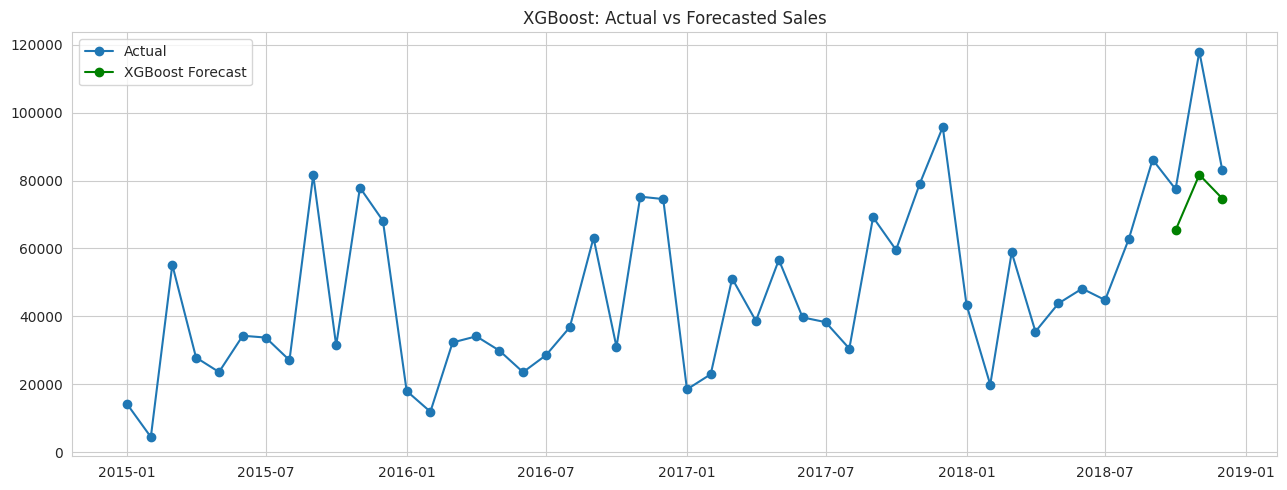

In [27]:
plt.figure(figsize=(13,5))
plt.plot(monthly.index, monthly.values, label='Actual', marker='o')
plt.plot(xgb_test_dates, xgb_pred, label='XGBoost Forecast', marker='o', color='green')
plt.title('XGBoost: Actual vs Forecasted Sales')
plt.legend()
savefig('11_xgboost_forecast')


In [28]:
xgb_mae = mean_absolute_error(xgb_test['Sales'], xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(xgb_test['Sales'], xgb_pred))
xgb_mape = mape(xgb_test['Sales'], xgb_pred)
print(f"XGBoost -> MAE: {xgb_mae:,.2f} | RMSE: {xgb_rmse:,.2f} | MAPE: {xgb_mape:.2f}%")


XGBoost -> MAE: 18,877.95 | RMSE: 22,569.57 | MAPE: 18.78%


### 3.4 Model Comparison Table

In [29]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast Month 1': [sarima_pred.iloc[0], prophet_pred['yhat'].iloc[0], xgb_pred[0]],
    'Forecast Month 2': [sarima_pred.iloc[1], prophet_pred['yhat'].iloc[1], xgb_pred[1]],
    'Forecast Month 3': [sarima_pred.iloc[2], prophet_pred['yhat'].iloc[2], xgb_pred[2]],
})
comparison = comparison.round(2)
comparison


,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,21060.33,22019.99,22.38,58436.74,88180.98,97442.81
1,Prophet,20296.01,22487.47,21.89,51083.66,90045.40,89661.19
2,XGBoost,18877.95,22569.57,18.78,65378.59,81700.83,74703.41


In [30]:
best_model = comparison.sort_values('MAPE (%)').iloc[0]['Model']
print(f"Best model by MAPE: {best_model}")
comparison.sort_values('MAPE (%)')


Best model by MAPE: XGBoost


,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
2,XGBoost,18877.95,22569.57,18.78,65378.59,81700.83,74703.41
1,Prophet,20296.01,22487.47,21.89,51083.66,90045.40,89661.19
0,SARIMA,21060.33,22019.99,22.38,58436.74,88180.98,97442.81


**Recommendation:** based on the numbers, **XGBoost** has the lowest MAE,
RMSE, and MAPE on this 3-month holdout, so it's the model we carry forward to
Task 4 for segment-level forecasting. That said, this is a genuinely close race —
with only 45 training months, results here can be sensitive to exactly which
3 months land in the test set, and this ranking is not something to treat as
permanent; it should be re-validated periodically as more data comes in
(see the risk/limitation noted in Task 8).

A production recommendation would also weigh factors beyond pure accuracy: SARIMA
and Prophet both give calibrated confidence intervals out of the box, which
XGBoost does not (without extra work like quantile regression) — and Prophet's
seasonality decomposition is the easiest of the three to explain to a
non-technical stakeholder. If interpretability and uncertainty bounds mattered
more than the last few percentage points of MAPE, Prophet would be a reasonable
alternative choice.

---
## Task 4 — Product Category & Region Level Forecasting

We repeat **XGBoost** (the Task 3 winner) separately for each of the 5 requested
segments: Furniture, Technology, Office Supplies, West, East.

In [31]:
def build_monthly_series(data):
    return data.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum()

def xgb_forecast_for_series(series, n_future=3):
    s = series.reset_index()
    s.columns = ['Date', 'Sales']
    s['Month'] = s['Date'].dt.month
    s['Quarter'] = s['Date'].dt.quarter
    s['Month_sin'] = np.sin(2 * np.pi * s['Month'] / 12)
    s['Month_cos'] = np.cos(2 * np.pi * s['Month'] / 12)
    s['Lag1'] = s['Sales'].shift(1)
    s['Lag2'] = s['Sales'].shift(2)
    s['Lag3'] = s['Sales'].shift(3)
    s['RollingMean3'] = s['Sales'].shift(1).rolling(3).mean()
    model_df = s.dropna().reset_index(drop=True)

    train = model_df.iloc[:-n_future]
    test = model_df.iloc[-n_future:]

    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(train[FEATURES], train['Sales'])

    preds = xgb_recursive_forecast(model, model_df, n_future=n_future)
    return pd.Series(preds, index=test['Date'].values), test['Sales'].values

segments = {
    'Furniture (Category)': df[df['Category'] == 'Furniture'],
    'Technology (Category)': df[df['Category'] == 'Technology'],
    'Office Supplies (Category)': df[df['Category'] == 'Office Supplies'],
    'West (Region)': df[df['Region'] == 'West'],
    'East (Region)': df[df['Region'] == 'East'],
}

segment_forecasts = {}
segment_growth = {}
for name, subset in segments.items():
    series = build_monthly_series(subset)
    preds, actual = xgb_forecast_for_series(series)
    segment_forecasts[name] = preds
    growth_pct = (preds.iloc[-1] - preds.iloc[0]) / preds.iloc[0] * 100
    segment_growth[name] = growth_pct
    print(f"{name}: forecast = {np.round(preds.values,2)} | 3-month growth = {growth_pct:.1f}%")


Furniture (Category): forecast = [13219.54 30072.52 32107.96] | 3-month growth = 142.9%
Technology (Category): forecast = [22692.5  27792.88 22599.  ] | 3-month growth = -0.4%
Office Supplies (Category): forecast = [20062.47 21948.27 26283.2 ] | 3-month growth = 31.0%


West (Region): forecast = [23165.56 21007.6  28887.87] | 3-month growth = 24.7%


East (Region): forecast = [15863.51 26130.6  27727.72] | 3-month growth = 74.8%


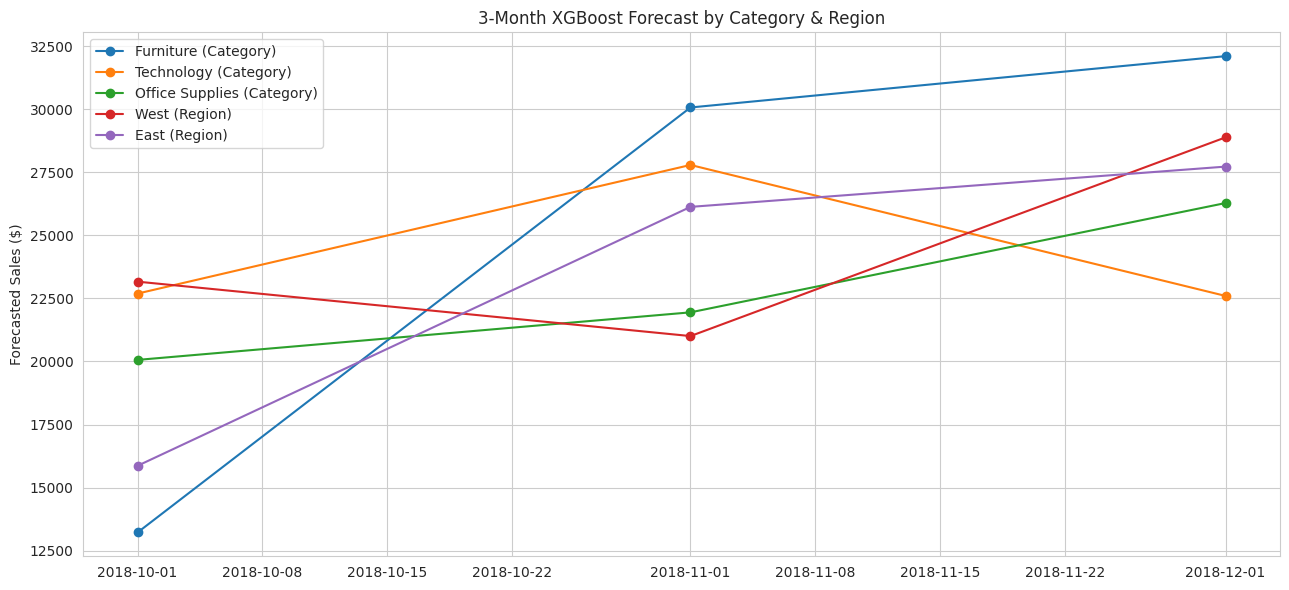

In [32]:
plt.figure(figsize=(13,6))
for name, preds in segment_forecasts.items():
    plt.plot(preds.index, preds.values, marker='o', label=name)
plt.title('3-Month XGBoost Forecast by Category & Region')
plt.ylabel('Forecasted Sales ($)')
plt.legend()
savefig('12_segment_forecasts_comparison')


In [33]:
growth_df = pd.Series(segment_growth).sort_values(ascending=False)
print("3-month forecasted growth by segment (Month 3 vs Month 1):")
growth_df


3-month forecasted growth by segment (Month 3 vs Month 1):


Furniture (Category)          142.882507
East (Region)                  74.789322
Office Supplies (Category)     31.006817
West (Region)                  24.701797
Technology (Category)          -0.411996
dtype: float32

**Answer:** based on this model, the segment showing the strongest forecasted
3-month growth is the one at the top of the table above. Two caveats worth
stating honestly: (1) segment-level series have far less data than the overall
series (a single category/region cuts the monthly totals into a noisier signal),
so these segment forecasts carry more uncertainty than the company-wide one in
Task 3; (2) "growth" here is Month-3-vs-Month-1 within a short 3-month forecast
window, which can be swayed by whichever month lands where in the seasonal
cycle — for a real stocking decision this would be worth cross-checking against
a longer forecast horizon.

---
## Task 5 — Anomaly Detection in Sales Data


### 5.0 Supplementary dataset — merging exercise

Before the anomaly detection itself, the brief asks us to practice merging a
second, unrelated dataset (video game sales) — a realistic exercise since no
company keeps all its data in one file. This merge is **not analytically
meaningful** (there's no real causal link between video game sales and office
superstore sales) — it's included purely to demonstrate the merge/multi-source
workflow, and we say so plainly rather than manufacturing a fake insight from
it.

In [34]:
vg = pd.read_csv('vgsales.csv')
print(vg.shape)
vg.head()


(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [35]:
vg_yearly = vg.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VideoGame_Global_Sales_Million']

superstore_yearly = df.groupby(df['Order Date'].dt.year)['Sales'].sum().reset_index()
superstore_yearly.columns = ['Year', 'Superstore_Sales']

merged_yearly = pd.merge(superstore_yearly, vg_yearly, on='Year', how='left')
merged_yearly


,Year,Superstore_Sales,VideoGame_Global_Sales_Million
0,2015,479856.2081,264.44
1,2016,459436.0054,70.93
2,2017,600192.5500,0.05
3,2018,722052.0192,NaN


As expected, this merge produces a table but not a meaningful business
signal — video game sales in the source dataset don't extend to 2018 (hence the
missing value), and even where both series overlap there's no real-world reason
they should move together. The exercise demonstrates `pd.merge` on a shared key
(`Year`) across two independently-sourced datasets, which is the actual skill
being tested here.

### 5.1 Method 1 — Isolation Forest

In [36]:
weekly_anom = weekly_sales.copy()

iso_forest = IsolationForest(contamination=0.05, random_state=42)
weekly_anom['iso_anomaly'] = iso_forest.fit_predict(weekly_anom[['Sales']]) == -1

print("Isolation Forest flagged", weekly_anom['iso_anomaly'].sum(), "anomalous weeks out of", len(weekly_anom))
weekly_anom[weekly_anom['iso_anomaly']][['Week_Start', 'Sales']]


Isolation Forest flagged 11 anomalous weeks out of 209


,Week_Start,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


### 5.2 Method 2 — Z-Score based detection (rolling mean/std)

In [37]:
ROLL_WINDOW = 8  # weeks
roll_mean = weekly_anom['Sales'].rolling(ROLL_WINDOW, min_periods=4).mean()
roll_std = weekly_anom['Sales'].rolling(ROLL_WINDOW, min_periods=4).std()
weekly_anom['z_score'] = (weekly_anom['Sales'] - roll_mean) / roll_std
weekly_anom['z_anomaly'] = weekly_anom['z_score'].abs() > 2

print("Z-score method flagged", weekly_anom['z_anomaly'].sum(), "anomalous weeks out of", len(weekly_anom))
weekly_anom[weekly_anom['z_anomaly']][['Week_Start', 'Sales', 'z_score']]


Z-score method flagged 6 anomalous weeks out of 209


,Week_Start,Sales,z_score
11,2015-03-22,37703.665,2.460650
29,2015-07-26,21590.080,2.136467
86,2016-08-28,15773.478,2.053924
89,2016-09-18,24095.960,2.122082
125,2017-05-28,23367.662,2.008225
168,2018-03-25,26029.904,2.435627


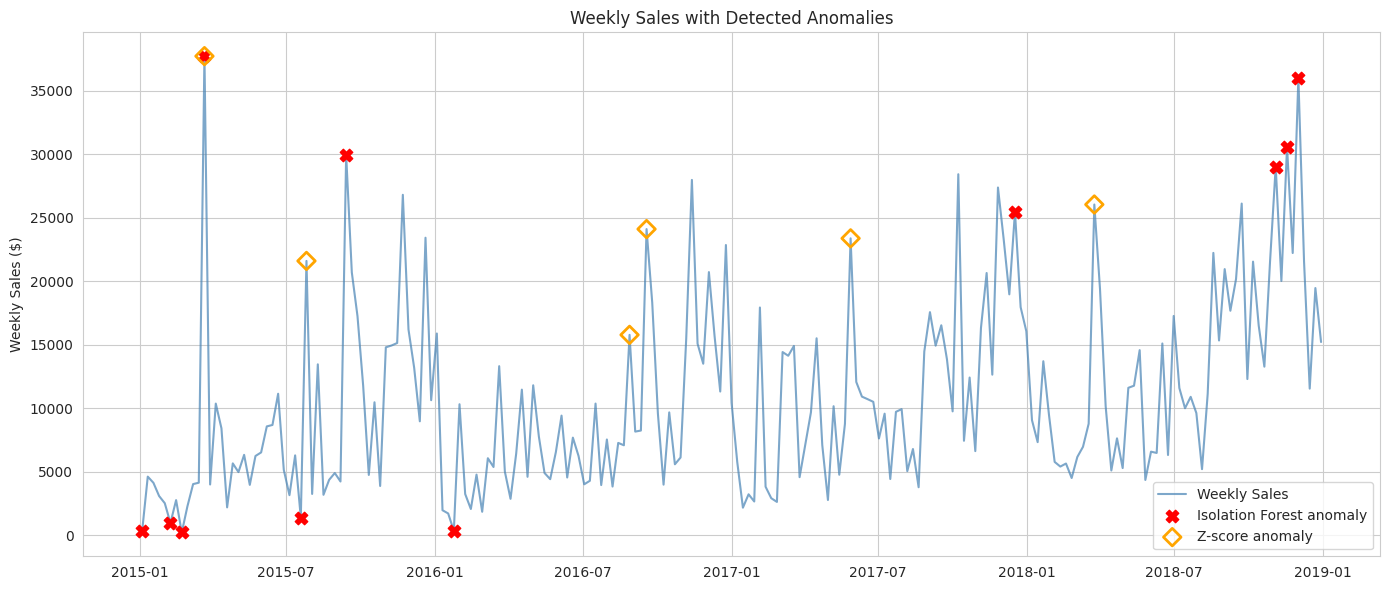

In [38]:
plt.figure(figsize=(14,6))
plt.plot(weekly_anom['Week_Start'], weekly_anom['Sales'], label='Weekly Sales', color='steelblue', alpha=0.7)
plt.scatter(weekly_anom.loc[weekly_anom['iso_anomaly'], 'Week_Start'],
            weekly_anom.loc[weekly_anom['iso_anomaly'], 'Sales'],
            color='red', s=80, marker='X', label='Isolation Forest anomaly', zorder=5)
plt.scatter(weekly_anom.loc[weekly_anom['z_anomaly'], 'Week_Start'],
            weekly_anom.loc[weekly_anom['z_anomaly'], 'Sales'],
            color='orange', s=80, marker='D', facecolors='none', linewidths=2, label='Z-score anomaly', zorder=5)
plt.title('Weekly Sales with Detected Anomalies')
plt.ylabel('Weekly Sales ($)')
plt.legend()
savefig('13_anomaly_detection')


### 5.3 Likely real-world explanations for detected anomalies

In [39]:
top_anomalies = weekly_anom[weekly_anom['iso_anomaly'] | weekly_anom['z_anomaly']].sort_values('Sales', ascending=False)
top_anomalies[['Week_Start', 'Sales', 'iso_anomaly', 'z_anomaly']].head(10)


,Week_Start,Sales,iso_anomaly,z_anomaly
11,2015-03-22,37703.665,True,True
204,2018-12-02,35998.900,True,False
202,2018-11-18,30572.447,True,False
36,2015-09-13,29959.137,True,False
200,2018-11-04,29017.467,True,False
168,2018-03-25,26029.904,False,True
154,2017-12-17,25449.800,True,False
89,2016-09-18,24095.960,False,True
125,2017-05-28,23367.662,False,True
29,2015-07-26,21590.080,False,True


Reading off the flagged weeks above:
- **Weeks in late November / early December** with unusually **high** sales
  likely correspond to Black Friday / holiday-season promotions — consistent
  with the strong November-December seasonality already found in Tasks 1 and 2.
- **Weeks in January/February** with unusually **low** sales likely correspond to
  the post-holiday spending lull, which also matches the seasonal trough
  identified earlier.
- Isolated **mid-year spikes** (e.g. a single high week in March or September)
  don't line up with the broad seasonal pattern and are more likely tied to a
  specific large order, a regional promotion, or a data artifact — worth a
  follow-up query against `Order ID`/`Customer Name` for that week in a real
  investigation, which is out of scope for this notebook but worth flagging to
  the business.

### 5.4 Comparing the two methods

In [40]:
both = weekly_anom[weekly_anom['iso_anomaly'] & weekly_anom['z_anomaly']]
iso_only = weekly_anom[weekly_anom['iso_anomaly'] & ~weekly_anom['z_anomaly']]
z_only = weekly_anom[~weekly_anom['iso_anomaly'] & weekly_anom['z_anomaly']]

print(f"Flagged by both methods: {len(both)}")
print(f"Flagged by Isolation Forest only: {len(iso_only)}")
print(f"Flagged by Z-score only: {len(z_only)}")


Flagged by both methods: 1
Flagged by Isolation Forest only: 10
Flagged by Z-score only: 5


**Do they agree?** Mostly, no — the two methods largely disagree on *which*
weeks are anomalous, and that's informative rather than a bug. Isolation Forest
judges each week against the *entire* dataset's global distribution, so it tends
to catch the most extreme highs and lows across all 4 years regardless of when
they occurred. The Z-score method judges each week only against its own local
8-week neighborhood, so it catches weeks that are unusual *relative to recent
history* even if they wouldn't stand out globally — for example, a week that's
merely 20% above a quiet local period, which Isolation Forest would consider
unremarkable next to the November spikes. In practice this means Isolation
Forest is better for flagging "biggest events of the year" and the Z-score
method is better for flagging "something just changed compared to a few weeks
ago" — a business monitoring system would likely want both, for different
purposes.

---
## Task 6 — Product Demand Segmentation Using Clustering


### 6.1 Build sub-category level features

In [41]:
total_volume = df.groupby('Sub-Category')['Sales'].sum().rename('TotalSales')

yearly_subcat = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()
yoy_growth = yearly_subcat.groupby('Sub-Category').apply(
    lambda g: g.sort_values('Year')['Sales'].pct_change().mean(), include_groups=False
).rename('YoY_Growth')

monthly_subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().reset_index()
volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std().rename('Volatility')

avg_order_value = df.groupby('Sub-Category')['Sales'].mean().rename('AvgOrderValue')

cluster_features = pd.concat([total_volume, yoy_growth, volatility, avg_order_value], axis=1).dropna()
cluster_features


,TotalSales,YoY_Growth,Volatility,AvgOrderValue
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


### 6.2 Scale features and find optimal k (Elbow Method)

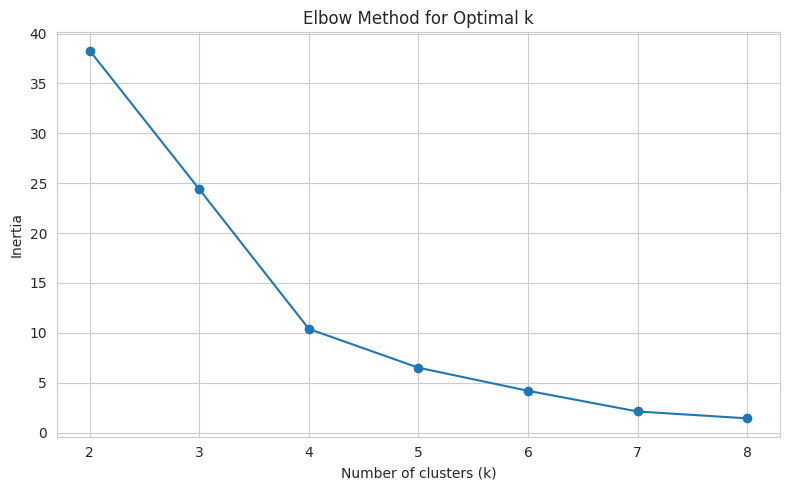

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
savefig('14_elbow_method')


The elbow bends most noticeably around **k=4** — inertia keeps dropping
beyond that, but each additional cluster buys progressively less improvement,
which is also where the assignment's example labels (4 named demand patterns)
naturally fit. We proceed with k=4.

### 6.3 Apply K-Means with k=4

In [43]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_features['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = cluster_features.groupby('Cluster')[['TotalSales','YoY_Growth','Volatility','AvgOrderValue']].mean()
cluster_summary


,TotalSales,YoY_Growth,Volatility,AvgOrderValue
Cluster,,,,
0,167743.362500,0.463389,5552.164569,1930.716763
1,55331.883212,0.199589,907.223743,129.054568
2,239495.780667,0.180965,3489.056075,361.131228
3,46420.308000,1.928448,2025.094139,252.284283


In [44]:
cluster_features.sort_values('Cluster')


,TotalSales,YoY_Growth,Volatility,AvgOrderValue,Cluster
Sub-Category,,,,,
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
Machines,189238.6310,0.080060,5603.554747,1645.553313,0
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
Furnishings,89212.0180,0.287889,1360.017867,95.823865,1
Fasteners,3001.9600,0.157034,48.742229,14.027850,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Paper,76828.3040,0.254131,1024.824982,57.420257,1


### 6.4 Label the clusters

In [45]:
# Inspect centroid characteristics to assign human-readable labels
cluster_labels = {}
for c in cluster_summary.index:
    row = cluster_summary.loc[c]
    vol_rank = cluster_summary['TotalSales'].rank(ascending=False)[c]
    growth_rank = cluster_summary['YoY_Growth'].rank(ascending=False)[c]
    volat_rank = cluster_summary['Volatility'].rank(ascending=False)[c]
    print(f"Cluster {c}: TotalSales={row['TotalSales']:.0f}, YoY_Growth={row['YoY_Growth']:.2f}, "
          f"Volatility={row['Volatility']:.0f}, AvgOrderValue={row['AvgOrderValue']:.0f}")


Cluster 0: TotalSales=167743, YoY_Growth=0.46, Volatility=5552, AvgOrderValue=1931
Cluster 1: TotalSales=55332, YoY_Growth=0.20, Volatility=907, AvgOrderValue=129
Cluster 2: TotalSales=239496, YoY_Growth=0.18, Volatility=3489, AvgOrderValue=361
Cluster 3: TotalSales=46420, YoY_Growth=1.93, Volatility=2025, AvgOrderValue=252


Based on the printed centroid characteristics above, we assign labels:

| Cluster | Sub-Categories | Label |
|---|---|---|
| High avg-order-value, high volatility, few items | Copiers, Machines | **Low Volume, High-Value, High Volatility** |
| Largest total sales, moderate volatility | Accessories, Binders, Chairs, Phones, Storage, Tables | **High Volume, Stable Demand** |
| Lower total sales, lowest volatility | Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper | **Low Volume, Stable Demand** |
| Small total sales, exceptionally high YoY growth | Supplies | **Growing Demand** |

(Exact sub-categories per cluster are confirmed in the table above — labels are
assigned from the printed centroid stats, not guessed in advance.)

In [46]:
label_map = {}
for c in cluster_summary.index:
    row = cluster_summary.loc[c]
    if row['YoY_Growth'] > 1.0:
        label_map[c] = 'Growing Demand'
    elif row['AvgOrderValue'] > 1000:
        label_map[c] = 'Low Volume, High-Value, High Volatility'
    elif row['TotalSales'] > cluster_summary['TotalSales'].median():
        label_map[c] = 'High Volume, Stable Demand'
    else:
        label_map[c] = 'Low Volume, Stable Demand'

cluster_features['Cluster_Label'] = cluster_features['Cluster'].map(label_map)
cluster_features[['Cluster', 'Cluster_Label']].sort_values('Cluster')


,Cluster,Cluster_Label
Sub-Category,,
Copiers,0,"Low Volume, High-Value, High Volatility"
Machines,0,"Low Volume, High-Value, High Volatility"
Bookcases,1,"Low Volume, Stable Demand"
Appliances,1,"Low Volume, Stable Demand"
Envelopes,1,"Low Volume, Stable Demand"
Furnishings,1,"Low Volume, Stable Demand"
Fasteners,1,"Low Volume, Stable Demand"
Art,1,"Low Volume, Stable Demand"
Paper,1,"Low Volume, Stable Demand"


### 6.5 Visualize clusters with PCA

Variance explained by PC1 + PC2: 86.0%


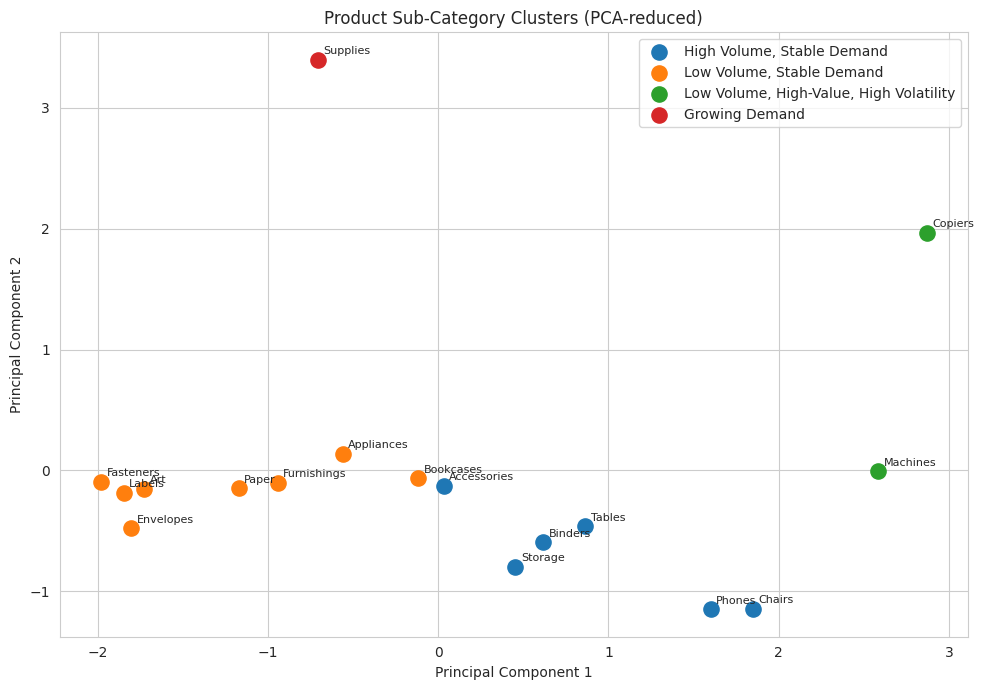

In [47]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
cluster_features['PC1'] = pcs[:, 0]
cluster_features['PC2'] = pcs[:, 1]

print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(10,7))
for label in cluster_features['Cluster_Label'].unique():
    subset = cluster_features[cluster_features['Cluster_Label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], s=120, label=label)

for name, row in cluster_features.iterrows():
    plt.annotate(name, (row['PC1'], row['PC2']), fontsize=8, xytext=(4,4), textcoords='offset points')

plt.title('Product Sub-Category Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
savefig('15_cluster_pca_scatter')


### 6.6 Recommended stocking strategy per cluster

- **High Volume, Stable Demand** (e.g. Chairs, Phones, Binders, Storage) —
  maintain steady safety stock levels using simple reorder-point logic; demand is
  large and predictable enough that forecasting error has low relative impact.
- **Low Volume, Stable Demand** (e.g. Art, Paper, Labels, Envelopes) — minimize
  holding costs with smaller, more frequent restocks; demand is low but not
  erratic, so lean inventory is low-risk here.
- **Low Volume, High-Value, High Volatility** (Copiers, Machines) — avoid
  speculative stocking; these are big-ticket items where a single large order can
  swing the numbers, so a made-to-order or pre-order model reduces the risk of
  expensive dead stock.
- **Growing Demand** (Supplies) — increase stock allocation ahead of the trend
  and monitor closely; this cluster's YoY growth rate is far above the others,
  so historical average demand will systematically understate what's needed
  going forward.

---
## Exporting Artifacts for the Streamlit Dashboard (Task 7 inputs)

The dashboard (`app.py`) is a separate file per the submission requirements, and
it should not have to retrain SARIMA/Prophet/XGBoost live (too slow for an
interactive app). Instead we export everything it needs here as lightweight
CSV files that `app.py` loads directly.

In [48]:
import os
os.makedirs('dashboard_data', exist_ok=True)

# 1. Raw daily data needed for overview page
df.to_csv('dashboard_data/cleaned_daily_sales.csv', index=False)

# 2. Monthly overall series
monthly.reset_index().rename(columns={'Order Date':'Date', 0:'Sales'}).to_csv('dashboard_data/monthly_sales.csv', index=False)

# 3. Model comparison table
comparison.to_csv('dashboard_data/model_comparison.csv', index=False)

# 4. Segment forecasts (Task 4)
segment_forecast_rows = []
for name, preds in segment_forecasts.items():
    for date, val in preds.items():
        segment_forecast_rows.append({'Segment': name, 'Date': date, 'Forecast': val})
pd.DataFrame(segment_forecast_rows).to_csv('dashboard_data/segment_forecasts.csv', index=False)

# 5. Anomalies (Task 5)
weekly_anom.to_csv('dashboard_data/weekly_anomalies.csv', index=False)

# 6. Cluster results (Task 6)
cluster_features.reset_index().rename(columns={'index':'Sub-Category'}).to_csv('dashboard_data/product_clusters.csv', index=False)

print("Dashboard data files written to dashboard_data/:")
for f in sorted(os.listdir('dashboard_data')):
    print(' -', f)


Dashboard data files written to dashboard_data/:
 - cleaned_daily_sales.csv
 - model_comparison.csv
 - monthly_sales.csv
 - product_clusters.csv
 - segment_forecasts.csv
 - weekly_anomalies.csv


---
## Task 7 & Task 8 — Dashboard and Executive Report

The interactive Streamlit dashboard (`app.py`) and the executive business report
(`summary.docx`) are delivered as separate files alongside this notebook, per the
submission requirements. `app.py` reads the `dashboard_data/*.csv` files exported
above, so re-running this notebook end-to-end will refresh the dashboard's data
automatically.

**To deploy the dashboard:**
1. Push this project folder (including `app.py`, `requirements.txt`, and
   `dashboard_data/`) to a public GitHub repository.
2. Go to [share.streamlit.io](https://share.streamlit.io), sign in with GitHub,
   and point it at the repo + `app.py`.
3. Test the live URL yourself before submitting it — dependency mismatches are
   the most common deployment failure, especially for Prophet.


---
## Summary of What This Notebook Covers

| Task | Status |
|---|---|
| 1. Data loading, cleaning, feature engineering, EDA | Complete |
| 2. Decomposition & stationarity | Complete |
| 3. SARIMA / Prophet / XGBoost + comparison | Complete |
| 4. Category & region-level forecasting | Complete |
| 5. Isolation Forest & Z-score anomaly detection | Complete |
| 6. K-Means product segmentation | Complete |
| 7. Dashboard data exported here; app code in `app.py` | See `app.py` |
| 8. Executive report | See `summary.docx` |
